In [1]:
import unidecode # Imported unidecode package for de-accentation.

import pandas as pd # pandas: for working with tables (DataFrames). Read, clean, and analyze data.
import seaborn as sns # seaborn: for quick, nice-looking charts built on top of Matplotlib.
from matplotlib import pyplot as plt # matplotlib.pyplot: for creating figures and fine-tuning plots (size, titles, labels).
# matplotlib: a plotting library used to create and customize visual charts and figures in Python.
sns.set(font_scale=1.5) # Increases the font size of all Seaborn plot text by 1.5 times.

In [2]:
#Read the file cons_elec_france.csv as a Pandas dataframe :
import pandas as pd # pandas: for working with tables (DataFrames). Read, clean, and analyze data.
df_cons = pd.read_csv("cons_elec_france.csv") # Read the dataframe in the library 

In [3]:
# Display the first five lines of the df_cons by using the 
# "head" function :
df_cons.head() # Show the first 5 lines of the data frame

,2015-11-13;Entreprises;13882225479
0,2015-11-11;Professionnels;3746294820
1,2015-12-18;Professionnels;5523363437
2,2015-12-06;Résidentiels;22545973870
3,2015-10-30;Résidentiels;15903891494
4,2015-10-20;Entreprises;14862039750


In [4]:
# Display the last five lines of the df_cons by using 
# the "tail" function :
df_cons.tail(5) # Show the last 5 lines of the data frame

,2015-11-13;Entreprises;13882225479
7298,2017-01-31;Professionnels;6156059505
7299,2017-02-10;Résidentiels;26943398299
7300,2017-02-10;PME / PMI;6815115652
7301,2017-02-10;Professionnels;6983274500
7302,2017-03-11;Professionnels;4616006030


In [5]:
# Some information about the dataframe :
df_cons.info() # Debugging and confirmation information regarding cloumns and data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7303 entries, 0 to 7302
Data columns (total 1 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   2015-11-13;Entreprises;13882225479  7303 non-null   object
dtypes: object(1)
memory usage: 57.2+ KB


In [6]:
# The dataframe has no correct header and columns are not 
# separated correctly.
# Re-use the read_csv function and give the correct separator 
# and the following column name (look at online documentation):
colNames=["date", "client_category", "daily_consumption"] # Defining the column names
df_cons = pd.read_csv("cons_elec_france.csv", sep=";", names=colNames, header=None) #Inıtializing the dataframe with separator, column names and header.

In [7]:
# Once again use info() function on df_cons and pay attention to 
# dtype (data type)
df_cons.info() # Debugging and confirmation information regarding cloumns and data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7304 entries, 0 to 7303
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               7304 non-null   object
 1   client_category    7304 non-null   object
 2   daily_consumption  7304 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 171.3+ KB


In [8]:
#datetime conversion
df_cons["date"] = pd.to_datetime(df_cons["date"], 
                                 format="%Y-%m-%d", 
                                 errors="coerce") # Conversion of dates to datetime data type from object data type
df_cons.dtypes # Debugging for data types
# Question : what are the role of format and errors ?

date                 datetime64[ns]
client_category              object
daily_consumption             int64
dtype: object

In [9]:
# float conversion
df_cons["daily_consumption"] = \
    df_cons["daily_consumption"].astype(float)
df_cons.dtypes

date                 datetime64[ns]
client_category              object
daily_consumption           float64
dtype: object

In [10]:
# Drop the duplicated rows :
df_cons = df_cons.drop_duplicates() # Removing the duplicates from the dataframe
df_cons.info() # Debugging and confirmation information regarding cloumns and data types.
# Question : Were there any duplicated rows ?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7304 entries, 0 to 7303
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               7304 non-null   datetime64[ns]
 1   client_category    7304 non-null   object        
 2   daily_consumption  7304 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 171.3+ KB


In [11]:
df_cons.shape # ".shape" method displays the row and column count in a tuple format.

(7304, 3)

In [12]:
# Use describe method to have some statistical info
df_cons.describe() # .describe() function displays descriptive statistics regarding the dataframe. 

,date,daily_consumption
count,7304,7.304000e+03
mean,2016-02-23 12:00:00.000000256,9.882748e+09
min,2013-08-25 00:00:00,2.812475e+09
25%,2014-11-24 00:00:00,4.720512e+09
50%,2016-02-23 12:00:00,8.149467e+09
75%,2017-05-25 00:00:00,1.401314e+10
max,2018-08-24 00:00:00,3.635733e+10
std,NaN,6.234929e+09


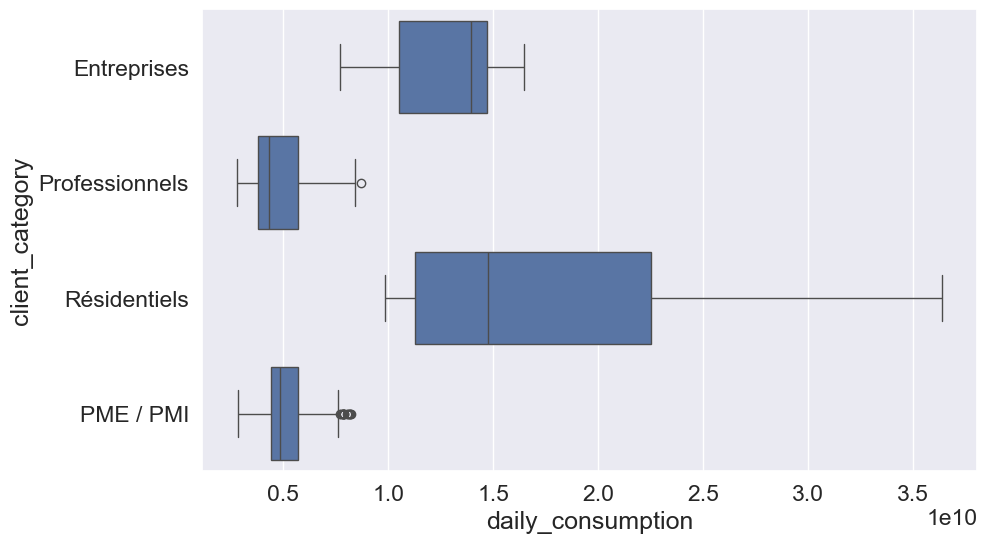

In [13]:
# Boxplot is a powerfull tool to illustraues the outliers. 
# Look for on-line documention on boxplots.
fig, ax = plt.subplots( figsize=(10, 6) ) # Matplotlib function that sizes the figures and axes.
sns.boxplot( data=df_cons, x="daily_consumption", 
             y="client_category", orient="h" ) # Initialization of boxplot via matplotlib.pyplot package
plt.show() # Displaying the table.

In [14]:
# Task : find the first and last dates in the dataframe : 
min_date = min(df_cons['date']) # Displays the minimum date in the dataframe
max_date = max(df_cons['date']) # Displays the maximum date in the dataframe
print(min_date, max_date)

2013-08-25 00:00:00 2018-08-24 00:00:00


In [15]:
# Task : sort the df_cons by date by using sort_values method :
df_cons.sort_values("date", ignore_index=True, inplace=True) # Sorts the dataframe by the "date" column, resets the index to 0...n, and updates the original dataframe
print(df_cons)

           date client_category  daily_consumption
0    2013-08-25    Résidentiels       1.131514e+10
1    2013-08-25     Entreprises       8.385337e+09
2    2013-08-25  Professionnels       3.076408e+09
3    2013-08-25       PME / PMI       3.297476e+09
4    2013-08-26  Professionnels       3.568823e+09
...         ...             ...                ...
7299 2018-08-23     Entreprises       1.328262e+10
7300 2018-08-24       PME / PMI       4.913384e+09
7301 2018-08-24  Professionnels       3.624391e+09
7302 2018-08-24    Résidentiels       1.038747e+10
7303 2018-08-24     Entreprises       1.261049e+10

[7304 rows x 3 columns]


In [16]:
# Task : add a new column "year" to df_cons that contains 
#        the year for each entry.
# Hint : you should extract year from df_cons["date"]
df_cons["year"] = df_cons["date"].dt.year # Initializing a new year column, extracting only the year from the dataframe and implements it into the new defined column.  
print(df_cons["year"])

0       2013
1       2013
2       2013
3       2013
4       2013
        ... 
7299    2018
7300    2018
7301    2018
7302    2018
7303    2018
Name: year, Length: 7304, dtype: int32


In [17]:
# Task : find the unique categories in client_category 
#   columns by applying the unique() method.
df_cons["client_category"].unique() # Displays unique values in a selected column in an array format and showing the data type 

array(['Résidentiels', 'Entreprises', 'Professionnels', 'PME / PMI'],
      dtype=object)

In [18]:
# Task : explain the following code :
df_cons["client_category"] = \
    df_cons["client_category"].str.lower() # Makes all of the letters lowercase.
df_cons["client_category"]

0         résidentiels
1          entreprises
2       professionnels
3            pme / pmi
4       professionnels
             ...      
7299       entreprises
7300         pme / pmi
7301    professionnels
7302      résidentiels
7303       entreprises
Name: client_category, Length: 7304, dtype: object

In [19]:
# Removing the accents from client_category column
df_cons["client_category"] = \
    df_cons["client_category"].apply(unidecode.unidecode) # Removing accents in the strings.

In [20]:
#Initializing a new dataframe, grouping by client_category, taking the mean of the daily_consumption, resetting the indexes for tidyness, sorting of the values and renaming the column for the mean values.
df_cl_cons = df_cons[["daily_consumption", "client_category"]]\
    .groupby( "client_category" )\
    .mean()\
    .reset_index()\
    .sort_values("daily_consumption")\
    .rename( columns={"daily_consumption" : "mean_daily_consumption"} )

df_cl_cons

,client_category,mean_daily_consumption
2,professionnels,4.737157e+09
1,pme / pmi,4.999475e+09
0,entreprises,1.286533e+10
3,residentiels,1.692903e+10


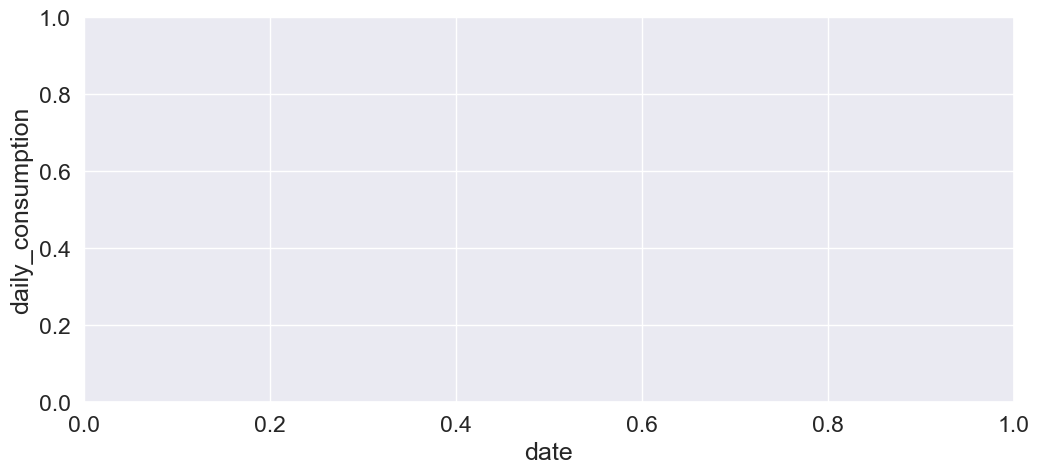

In [21]:
# Task : From df_cons select data for 2016 with "residentiels" and 
#        "entreprises" as clients. Make a lineplot for  
#        daily_consumption versus date for the two different 
#        client categoris.


# Fixed filtering condition using the conditional module for "year" and isin() method to select multiple categories, in this instance "client_category". 
df_2016 = df_cons[
    (df_cons["year"] == 2016) &
    (df_cons["client_category"].isin(["Residentiels", "Entreprises"]))
].copy()

# 2) Sort to get a clean line
df_2016 = df_2016.sort_values("date")

fig, ax = plt.subplots(figsize=(12, 5)) # Matplotlib figure and axes initialization and size-configuration.
sns.lineplot(data=df_2016, x="date", y="daily_consumption", hue="client_category") # Definition of x and y-axis and hue variable to indicate client_category.
plt.show() # Display the lineplot

Exercises
groupby followed by multiple aggregation

Regroup the df_cons dataframe by client_category and year then find a method that make a sum over daily_consumption and count on date. 

Sort the regrouped dataframe by daily_consumption and rename the columns as : "client_category", "year", "yearly_consumption" and "n_days".

Display the regrouped dataframe.
Make a barplot that shows the some of yearly_consumption versus n_days for different client categories.
Mean consumption per weekdays

From df_cons select data for 2017 and residential category. Extract the week day names from the date column. Compute the mean consumption per day.

Make lineplot for mean consumption versus week day.
How do you interpret the plot ?

In [22]:
import unidecode # Removing accent signs in differentiating latin alphabet letters

import pandas as pd # pandas: for working with tables (DataFrames). Read, clean, and analyze data.
import seaborn as sns # seaborn: for quick, nice-looking charts built on top of Matplotlib.
from matplotlib import pyplot as plt # matplotlib.pyplot: for creating figures and fine-tuning plots (size, titles, labels).
# matplotlib: a plotting library used to create and customize visual charts and figures in Python.

sns.set(font_scale=1.5) # Increases the font size of all Seaborn plot text by 1.5 times.

In [23]:
colNames=["date", "client_category", "daily_consumption"] # Column name list for the dataset
df_cons = pd.read_csv("cons_elec_france.csv", sep=";", names=colNames, header=None) # Reading the file, splitting the categories with a delimiter and giving name to columns.

In [24]:
df_cons.info() # Validation and debugging if the delimiter split and data count info are accurate.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7304 entries, 0 to 7303
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               7304 non-null   object
 1   client_category    7304 non-null   object
 2   daily_consumption  7304 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 171.3+ KB


In [25]:
df_cons["date"] = pd.to_datetime(df_cons["date"], # Conversion of dates to datetime data type from object data type for facilitating extracting the "Year" value.
                                 format="%Y-%m-%d", # Format selection for date display 
                                 errors="coerce") # Define exception if a particular data is not convertible into date format defined one line above.
df_cons["daily_consumption"] =  df_cons["daily_consumption"].astype(float) # Conversion to float64 from int64 for being able to show big ints with scientific notations. 
df_cons.dtypes # Debugging of the data types

date                 datetime64[ns]
client_category              object
daily_consumption           float64
dtype: object

In [26]:
df_cons["year"] = df_cons["date"].dt.year # Extract the year from the 'date' column into a new column (works directly with datetime64 datatype)

In [27]:
# 1st Cell code-line: Sorted the regrouped dataframe by "Daily Consumption" per the instructions.
# 2nd Cell code-line: Regrouping the dataframe by "Client Category" and "Year".
df_n_yearly_sum = df_cons.sort_values(by="daily_consumption")\
    .groupby(["client_category", "year"])\
    .agg(
         n_days=("date", "nunique"), # Counting distinct dates per year using the "nunique" function and aggregating the output as n_days to the dataframe with ".agg()" function.
         annual_consumption = ("daily_consumption", "sum") # Sum of "Daily Consumption" per "Client Category" and "Year" and, aggregating the output as annual_consumption to the dataframe with ".agg()" function.
    )\
    .reset_index() # For making the aggregated table “tidy” and easy to plot

df_n_yearly_sum # Displaying the regrouped dataframe

,client_category,year,n_days,annual_consumption
0,Entreprises,2013,129,1.702219e+12
1,Entreprises,2014,365,4.702533e+12
2,Entreprises,2015,365,4.732596e+12
3,Entreprises,2016,366,4.670841e+12
4,Entreprises,2017,365,4.666836e+12
5,Entreprises,2018,236,3.017074e+12
6,PME / PMI,2013,129,6.290443e+11
7,PME / PMI,2014,365,1.707706e+12
8,PME / PMI,2015,365,1.771248e+12
9,PME / PMI,2016,366,1.875980e+12


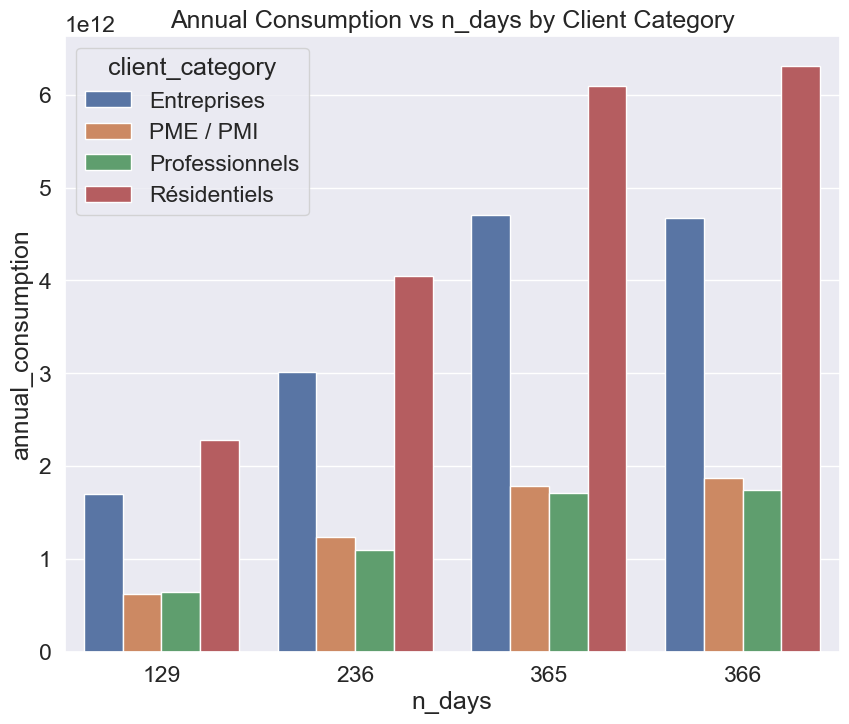

In [28]:
fig, ax = plt.subplots(figsize=(10, 8)) #Matplotlib figure and axes initialization and size-configuration
sns.barplot(x="n_days", y="annual_consumption", hue="client_category",
                data=df_n_yearly_sum, errorbar=None) #Initializing the barplot and defining the axes in the coordinate plane for barplot, also deleting the errorbars via "errorbar=None"
ax.set_title("Annual Consumption vs n_days by Client Category") #Setting title for the coordinate plane in general
ax.set_xlabel("n_days") # Setting the title for x-axis
ax.set_ylabel("annual_consumption") # Setting the title for y-axis
plt.show() # Showing the barplot

# Since the value "365" is displayed in multiple years, Seaborn groups them together and displays the mean for those bars. If we want the sum for value "365", we would only add "estimator=True" in the sns.barplot() function.

In [29]:
df_cons["client_category"] = df_cons["client_category"].apply(unidecode.unidecode) # Normalized "Client Category" strings by removing accents.
df_2017_wd = df_cons[(df_cons["year"] == 2017) & 
    (df_cons["client_category"] == "Residentiels")
    ].copy() # Selected particular data for residential clients in 2017 and made a partial copy of "df_cons" dataframe to avoid "SettingWithCopyWarning" Panda error causing by ".dt.day_name()" function.
df_2017_wd["weekday"] = df_2017_wd["date"].dt.day_name() # Extraction of Weekday names via datetime (dt) function.

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"] # Define the correct weekday order to ensure proper sorting instead of alphabetical which is the default of Panda.
df_2017_wd["weekday"] = pd.Categorical(df_2017_wd["weekday"], categories=order, ordered=True) # Convert "Weekday" to an ordered categorical type, using the given list as the fixed category order 
# "categories=order" sets allowed values and their order, ordered=True maintains the order that we gave initially for sorting and plotting.
df_2017_wd = df_2017_wd.sort_values("weekday") # Sorted the "Weekday" column per the order we provided.

In [30]:
# Group by 'Weekday' and 'Client Category', using observed=True to avoid the "FutureWarning" Panda error about unused category levels caused by ".sort_values("Weekday")" method.
df_2017_wd = df_2017_wd.groupby(["weekday", "client_category"], observed=True)\
    .agg(
        mean_daily_consumption=("daily_consumption", "mean") # Aggregation of Mean Daily Consumption per Weekdays into the dataframe.
    )\
    .reset_index() # For making the aggregated table “tidy” and easy to plot.

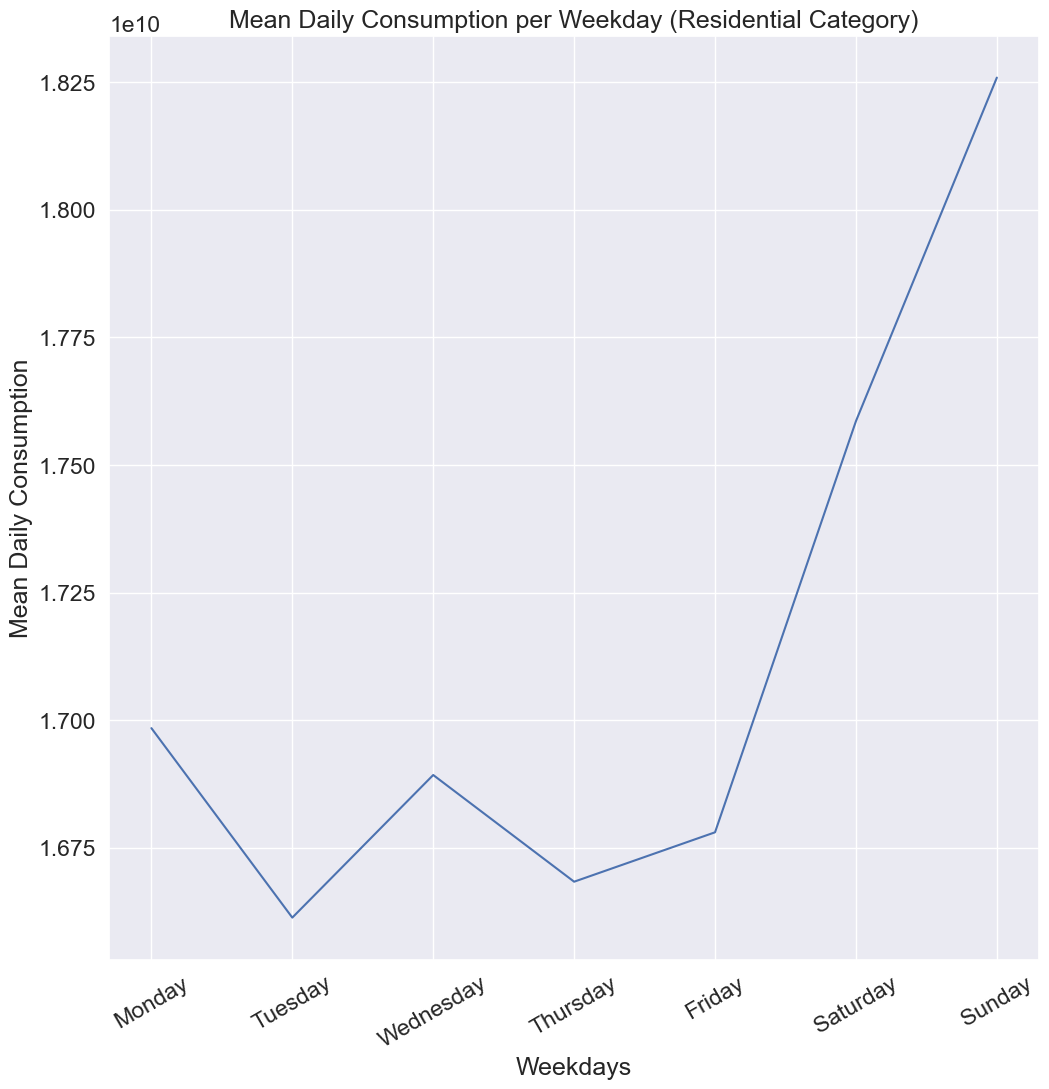

In [31]:
fig, ax = plt.subplots(figsize=(12, 12)) # Matplotlib figure and axes initialization and size-configuration.
sns.lineplot(x="weekday", y="mean_daily_consumption",
                data=df_2017_wd) # Initializing the lineplot and defining the axes in the coordinate plane for lineplot
ax.tick_params(axis="x", rotation=30) # Rotating the weekday names (located on x-axis) by 30 degrees.
ax.set_title("Mean Daily Consumption per Weekday (Residential Category)") # Setting title for the coordinate plane in general
ax.set_xlabel("Weekdays") # Setting the title for x-axis
ax.set_ylabel("Mean Daily Consumption") # Setting the title for y-axis
plt.show() # Showing the lineplot